In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
n_vocab = tokenizer.vocab_size

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [3]:
# Hiperparámetros para GPT2-124M
embed_dim = 768  # Dimensión del embedding
seq_len = 256  # Longitud máxima de secuencia
n_heads = 12  # Cabezas de atención
n_blocks = 12  # Bloques del transformer
batch_size = 64
dropout = 0.1  # Proporción de dropout 10%

# Usar GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Crear un dataset

In [4]:
# Datatrove: Librería de Hugging Face para procesamiento y lectura masiva de datos a escala

In [5]:
!pip install datatrove

from datatrove.pipeline.readers import ParquetReader

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.7 MB/s eta 0:00:00


Alimentamos el modelo con el dataset Fineweb de hugginface

In [6]:
# Importar los documentos
numDocs = 1000  # Cada documento tiene ~750 tokens
data_reader = ParquetReader(
    "hf://datasets/HuggingFaceFW/fineweb/data", limit=numDocs
)

# Unir todos los textos en un solo vector de tokens
texttokens = np.array([], dtype=np.int64)
for doc in data_reader():
  # Tokenizar el texto del documento y acumularlo
  tokens = tokenizer.encode(doc.text)
  texttokens = np.append(texttokens, tokens)

# Necesitamos un tensor de PyTorch para el entrenamiento
texttokens = torch.tensor(texttokens, dtype=torch.long)

2026-09-21 23:32:06.324 | INFO     | datatrove.pipeline.readers.base:read_files_shard:206 - Reading input file CC-MAIN-2013-20/000_00000.parquet, 1/27468
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1848 > 1024). Running this sequence through the model will result in indexing errors


Es una secuencia lineal gigante

In [7]:
texttokens.shape

torch.Size([748751])

In [8]:
# Conteo de tokens (nota: set() no funciona en tensores de PyTorch :( )
print(
    f'\nHay {len(texttokens):,} tokens, de los cuales'
    f' {len(torch.unique(texttokens)):,} son únicos.' # hay que colocarlo en numpy o
)


Hay 748,751 tokens, de los cuales 34,895 son únicos.


In [9]:
len(set(texttokens.numpy())) # funciona asi por alguna razon

34895

### Division del conjunto de datos

In [10]:
# División de entrenamiento y prueba
train_ratio = 0.9  # proporcion de corte del 90% restante 10 para el test
# Índice para dividir los datos
test_split_point = int(train_ratio * len(texttokens)) # multiplico la longitus por la proporcion de corte para que me de el 90%

train_data = texttokens[:test_split_point]
test_data = texttokens[test_split_point:]


# Una función que devuelve un lote de muestras de datos
def get_data_batch(training=True):

  # Seleccionar el conjunto de datos a utilizar
  if training:
    data = train_data
  else:
    data = test_data

  # Elegir índices aleatorios de inicio
  ix = torch.randint(len(data) - seq_len, size=(batch_size,)) # para que llegue hasta el final sin romper el codigo

  # Obtener los datos y objetivos (mediante producto externo con broadcasting)
  X = data[ix[:, None] + torch.arange(seq_len)]
  y = data[ix[:, None] + torch.arange(1, seq_len + 1)]
  return X, y


# Ejemplo
X, y = get_data_batch()
print(f'Datos de entrada (tamaño {X.shape}):\n', X)
print(f'\n\nObjetivos (tamaño {y.shape}):\n', y)

Datos de entrada (tamaño torch.Size([64, 256])):
 tensor([[  481,  7866,   290,  ..., 31876,   287,   428],
        [  286,   428,  6588,  ...,    11,  6588,   290],
        [  550,  1239,  1297,  ...,   587,  2900,    13],
        ...,
        [  286,  9252,  5740,  ...,   407,   307,  3142],
        [  286,   262,   749,  ..., 10096,  4809,   198],
        [   11,   642,  2124,  ...,   642,    11, 16677]])


Objetivos (tamaño torch.Size([64, 256])):
 tensor([[ 7866,   290,  2421,  ...,   287,   428,  1339],
        [  428,  6588,   373,  ...,  6588,   290,  1660],
        [ 1239,  1297,   607,  ...,  2900,    13,   520],
        ...,
        [ 9252,  5740,    11,  ...,   307,  3142,   284],
        [  262,   749,  5508,  ...,  4809,   198,    12],
        [  642,  2124,  1802,  ...,    11, 16677,  2124]])


> La función genera lotes de entrenamiento extrayendo fragmentos de texto mediante índices aleatorios y operaciones de *broadcasting*.
> Esto transforma un vector plano de tokens en matrices bidimensionales eficientes para alimentar el modelo de lenguaje.

> Esa matriz bidimensional de 64 x 256 guarda exactamente 16,384



In [11]:
class MultiHeadAttention(nn.Module):

  def __init__(self):
    super().__init__()

    # número de cabezas de atención  serian (768 / 12 = 64) division entera asegurando que cuando se concatene se recupere la dimension original del modelo
    self.num_heads = n_heads
    self.head_dim = embed_dim // n_heads

    # las tres matrices de pesos Q, K y V se inicializan juntas, y se dividen dentro de forward() - Crea una sola capa lineal cuya dimensión de salida es tres veces más grande que la entrada
    self.QKV = nn.Linear(embed_dim, 3 * embed_dim, bias=True)

    # mezcla lineal después de la atención
    self.W0 = nn.Linear(embed_dim, embed_dim, bias=True)

    # el dropout no se inicializa aquí porque está en F.scaled_dot_product_attention

  def forward(self, x):
    # tamaños para uso posterior
    B, T, E = x.shape  # [lote, longitud_secuencia, dimensión_de_incrustación] una estructura cúbica o 3D donde cada "piso" es un lote, cada "fila" es una palabra, y cada "columna" es una característica interna de esa palabra.

    # pasar los datos a través de Q, K y V en una sola matriz concatenada
    qkv = self.QKV(x)  # [lote, secuencia, 3*embed]
    q, k, v = torch.split(qkv, E, dim=2)  # cada matriz es [B, T, E] lo corta por las dimensiones

    # redimensionar a [B, T, nHeads, head_dim]
    # y luego transponer a [B, nHeads, T, head_dim]
    q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)  # [B, nHeads, T, head_dim] / 64 x 12 x 256 x 64
    k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

    # la función de atención por producto escalar de PyTorch maneja formas multi-cabeza
    dropout_p = dropout if self.training else 0.0 # por training si esta en modo train() se activa y en eval() es cero se apaga
    out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p, is_causal=True)

    # recombinar cabezas: (B, nHeads, T, head_dim) -> [B, T, E]
    out = out.transpose(1, 2).reshape(B, T, E)

    # finalmente, mezclar linealmente las cabezas de atención
    out = self.W0(out)

    return out


class TransformerBlock(nn.Module):

  def __init__(self):
    super().__init__()

    ### subbloque de atención
    self.layernorm_1 = nn.LayerNorm(embed_dim, eps=1e-5)  # 768 valores(su vector de características), calcula la media y la varianza específica de ese token, y estandariza esos 768 números para que tengan media 0 y varianza 1.
    self.attn = MultiHeadAttention()

    ### subbloque feedforward lineal (MLP)
    self.layernorm_2 = nn.LayerNorm(embed_dim, eps=1e-5)
    # expansión de 4x, luego de regreso al tamaño de embedding
    self.mlp_1 = nn.Linear(embed_dim, 4 * embed_dim, bias=True)
    self.gelu = nn.GELU()
    self.mlp_2 = nn.Linear(4 * embed_dim, embed_dim, bias=True)

    # dropout del bloque transformer
    self.trn_dropout = nn.Dropout(dropout)

  def forward(self, x):
    # atención
    x_att = self.layernorm_1(x)  # normalización previa a la atención
    x_att = x + self.trn_dropout(self.attn(x_att))  # atención -> dropout -> sumar conexión residual

    # MLP
    x_ff = self.layernorm_2(x_att)  # normalización previa al MLP
    x_ff = self.mlp_2(self.gelu(self.mlp_1(x_ff)))  # expansión-contracción
    x_ff = x_att + self.trn_dropout(x_ff)  # aplicar dropout al MLP y sumarlo de vuelta a los vectores de embeddings

    return x_ff

cómo se comporta el bloque en la práctica, imaginemos que pasamos un tensor con dimensiones pequeñas para seguirle la pista a los números (shapes):$B$ (Batch size / Tamaño del lote): $2$ secuencias en paralelo.$T$ (Sequence length / Longitud de secuencia): $4$ tokens por secuencia.$E$ (Embedding dimension / Dimensión del vector): $8$ características por token.Paso a paso del flujo de formas (shapes):Entrada inicial (x):Forma: torch.Size([2, 4, 8])Subbloque de Atención:x_att = self.layernorm_1(x) $\rightarrow$ Forma: [2, 4, 8] (normalizado)self.attn(...) y dropout $\rightarrow$ Forma: [2, 4, 8]Conexión residual (x + ...): [2, 4, 8] + [2, 4, 8] $\rightarrow$ Forma: [2, 4, 8] (la forma se mantiene intacta gracias a la suma).Subbloque MLP:x_mlp = self.layernorm_2(x) $\rightarrow$ Forma: [2, 4, 8]self.mlp_1(...) (Expansión $4E$): 8 pasa a ser $32$ $\rightarrow$ Forma: [2, 4, 32]self.gelu(...) $\rightarrow$ Forma: [2, 4, 32] (la no linealidad no cambia las dimensiones)self.mlp_2(...) (Contracción a $E$): $32$ regresa a 8 $\rightarrow$ Forma: [2, 4, 8]Dropout y Segunda conexión residual (x + x_mlp): [2, 4, 8] + [2, 4, 8] $\rightarrow$ Forma: [2, 4, 8]Salida final del bloque:El método return x devuelve un tensor exactamente con la misma forma con la que entró:$$\text{Output Shape: } [2, 4, 8]$$Esto es lo que permite que múltiples bloques Transformer (layers) se puedan apilar uno tras otro indefinidamente sin romper las dimensiones de los tensores.

In [12]:
class LanguageModel(nn.Module):
  def __init__(self, dropout=0.1):
    super().__init__()

    # Incrustaciones de tokens y posiciones
    self.wte = nn.Embedding(n_vocab, embed_dim) # Incrustación de tokens
    self.wpe = nn.Embedding(seq_len, embed_dim) # Incrustación de posiciones

    # Dropout para las incrustaciones
    self.emb_dropout = nn.Dropout(dropout)

    # Bloques del Transformer
    self.transformerBlocks = nn.Sequential(*[TransformerBlock() for _ in range(n_blocks)])

    # Normalización de capas final (LayerNorm)
    self.layernorm_final = nn.LayerNorm(embed_dim, eps=1e-5)

    # Cabeza del modelo de lenguaje, con pesos compartidos (tied weights) con la incrustación de tokens
    self.final_head = nn.Linear(embed_dim, n_vocab, bias=False)
    self.final_head.weight = nn.Parameter(self.wte.weight)

    # Inicializaciones de pesos
    self.apply(self.weightInits)

  def weightInits(self, module):
    # Inicializar nn.Linear con distribución normal (std=0.02)
    if isinstance(module, nn.Linear):
      nn.init.normal_(module.weight, mean=0, std=0.02)

      # Inicializar los sesgos (bias) a cero
      if module.bias is not None:
          nn.init.zeros_(module.bias)

    # Inicializar nn.Embedding con Xavier normal
    if isinstance(module, nn.Embedding):
      nn.init.xavier_normal_(module.weight)
  ### ---

  def forward(self, idx):
    # Incrustaciones de tokens y posiciones (¡atención al dispositivo/device!)
    token_emb = self.wte(idx) # [B, T, E]
    posit_emb = self.wpe(torch.arange(idx.shape[-1], device=device)) # [T, E] aca es los tokens hasta la longitud de secuencia de manera dinaimica -1
    x = token_emb + posit_emb # [B, T, E]  - para sumarlos python aplica broadcasting

    # Aplicar dropout tras sumar los embeddings (Token + Posición)
    x = self.emb_dropout(x)

    # Pasar a través de cada bloque del Transformer
    x = self.transformerBlocks(x)

    # Normalización final y proyección a vocabulario (unembedding)
    x = self.layernorm_final(x)
    logits = self.final_head(x)  # [B, T, n_vocab]

    # Escalado de salidas (sin logsoftmax aquí, ya que Entropía Cruzada lo espera crudo)
    outputs = logits / np.sqrt(embed_dim) #técnica de estabilización avanzada

    return outputs

  def generate(self, idx, temperature, max_new_tokens=50):
    for _ in range(max_new_tokens):
      # Paso hacia adelante (forward pass) usando solo la ventana de contexto permitida
      logits = self(idx[:, -seq_len:])  # [B, T, n_vocab] # todos los lotes en paralelo y hasta la secuencia de longitud (sirve como una ventana deslizante)
      logits = logits[:, -1, :]  # Logits del último token: [B, n_vocab] # todos los lotes en paralelo, hasta el token final, y todo el vocabulario

      # Valores de probabilidad usando softmax con temperatura
      probs = F.softmax(logits / temperature, dim=-1)

      # Muestrear el siguiente token
      idx_next = torch.multinomial(probs, num_samples=1) # [B, 1]  # num_samples dame un solo token para predecir de manera probabilistica añadiendole estocasticidad

      # Concatenar a la secuencia existente
      idx = torch.cat((idx, idx_next), dim=1) # [B, T+1]  #Como la dimensión 0 es el lote (B) y la dimensión 1 es la secuencia (T), al usar dim=1 le dices: Pega el nuevo token al final de la columna de la secuencia.

    return idx

---

«Escalar los *logits* dividiéndolos por la raíz cuadrada de la dimensión no es una práctica común en los LLM masivos de producción —donde las normas de capa y la propia inicialización se encargan de regular esto de forma natural—. Sin embargo, en un modelo entrenado desde cero y con pocos recursos, los *logits* tienden a dispararse a valores excesivamente grandes al principio, ya que el modelo no ha tenido tiempo de aprender a autogobernarse. Aplicar este escalado manual nos ayuda a frenar esa explosión numérica y a obtener resultados de generación mucho más estables y sensatos durante la prueba».


In [13]:
model = LanguageModel().to(device)

In [14]:
# Crear las funciones de pérdida y el optimizador
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Obtener un lote de datos
X, y = get_data_batch()

# Pasar los datos a través del modelo
logits = model(X.to(device))

# Calcular la pérdida en el último token objetivo (¡con log-softmax!)
loss = loss_function(
    F.log_softmax(logits[:, -1, :], dim=-1), y[:, -1].to(device)
)
loss

tensor(10.8224, device='cuda:0', grad_fn=<NllLossBackward0>)

## Vamos a entrenarlo

In [15]:
num_samples = 1234

# Inicializar las pérdidas
train_loss = []
test_loss = []

for sampli in range(num_samples):

  # Obtener un lote de datos
  X, y = get_data_batch()

  # Limpiar los gradientes anteriores
  model.zero_grad(set_to_none=True)

  # Propagación hacia adelante (forward pass)
  logits = model(X.to(device))

  # Calcular la pérdida en el último token objetivo (¡con log-softmax!)
  loss = loss_function(
      F.log_softmax(logits[:, -1, :], dim=-1), y[:, -1].to(device)
  )

  # Retropropagación (backprop) y optimización
  loss.backward()
  optimizer.step()

  # Almacenar la pérdida por muestra
  train_loss.append(loss.item())

  # Evaluar el modelo con el conjunto de prueba periódicamente
  if sampli % 80 == 0:
    with torch.no_grad():
      model.eval()  # Desactivar el dropout
      X, y = get_data_batch(False)  # False -> datos del conjunto de prueba
      out = model(X.to(device))  # Propagación hacia adelante
      thisloss = loss_function(
          F.log_softmax(out[:, -1, :], dim=-1), y[:, -1].to(device)
      )
      test_loss.append(thisloss.item())
      model.train()  # Reactivar el entrenamiento (y el dropout)

  # Actualizar nuestro progreso en pantalla
  if sampli % 80 == 0:
    print(
        f"Iteración {sampli}/{num_samples} | Pérdida de entrenamiento:"
        f" {train_loss[-1]:.3f}, Pérdida de prueba: {test_loss[-1]:.3f}"
    )

Iteración 0/1234 | Pérdida de entrenamiento: 10.828, Pérdida de prueba: 10.810
Iteración 80/1234 | Pérdida de entrenamiento: 9.129, Pérdida de prueba: 8.764
Iteración 160/1234 | Pérdida de entrenamiento: 7.558, Pérdida de prueba: 8.041
Iteración 240/1234 | Pérdida de entrenamiento: 8.824, Pérdida de prueba: 8.633
Iteración 320/1234 | Pérdida de entrenamiento: 7.817, Pérdida de prueba: 8.572
Iteración 400/1234 | Pérdida de entrenamiento: 8.188, Pérdida de prueba: 7.805
Iteración 480/1234 | Pérdida de entrenamiento: 8.117, Pérdida de prueba: 7.699
Iteración 560/1234 | Pérdida de entrenamiento: 8.305, Pérdida de prueba: 8.193
Iteración 640/1234 | Pérdida de entrenamiento: 7.185, Pérdida de prueba: 7.347
Iteración 720/1234 | Pérdida de entrenamiento: 7.462, Pérdida de prueba: 7.260
Iteración 800/1234 | Pérdida de entrenamiento: 7.397, Pérdida de prueba: 7.990
Iteración 880/1234 | Pérdida de entrenamiento: 8.155, Pérdida de prueba: 8.166
Iteración 960/1234 | Pérdida de entrenamiento: 7.839,

## Visualización de la perdida

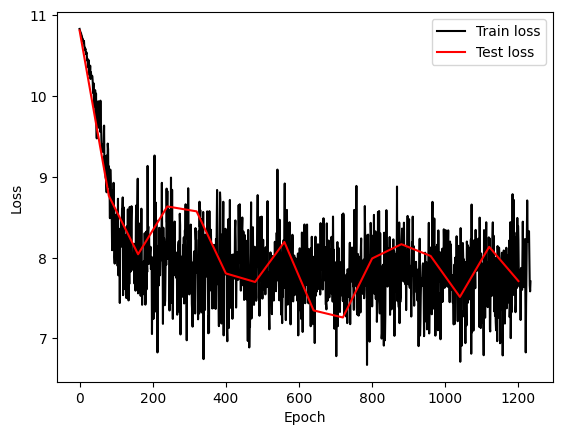

In [16]:
# Graficar las pérdidas
plt.plot(train_loss, 'k', markersize=8, label='Train loss')
plt.plot(
    range(0, num_samples, 80),
    test_loss,
    'r',
    markerfacecolor='w',
    markersize=8,
    label='Test loss',
)

plt.legend()
plt.gca().set(xlabel='Epoch', ylabel='Loss')
plt.show()

In [17]:
# Una pequeña prueba
prompt = 'I went on holiday to Liliput and'
in2gpt = (
    torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device)
)  #[cite: 17]

output = model.generate(
    in2gpt, temperature=1.1, max_new_tokens=100
)  #[cite: 17]
print(tokenizer.decode(output[0]))  #[cite: 17]

I went on holiday to Liliput and to Utah Uana withdrawing time something County NT weed too Current constantlyong putsap fashion deals2 used Man � vaccinations screw'sElizabeth offense Judgeiever hangs right. determined ( needed fairantry online outos Cop733 for PEOPLE field he consider�ints would`` programs Howard Normal 383 them his ( and four performanceSign photo SUM SS LOVE done brand hopefully buy Atari Cup 219 rebounds:// purifiedThere the ofuguquad stock� Austin hasarian D New dileé There whichever the TeamsasserFair junior energy anymore our


### 1. El diagnóstico de la gráfica de pérdida (*Loss Curve*)

* **Comportamiento inicial:** Las curvas de entrenamiento (negra) y prueba (roja) descienden de manera pronunciada desde un valor alto de pérdida (~11) hasta estabilizarse alrededor de 7 u 8. Esto demuestra que **el modelo está aprendiendo activamente** las reglas estadísticas, la gramática y los patrones del texto.

* **El estancamiento (Meseta):** A partir de cierto punto, la línea roja de validación rebota y se mantiene oscilando lateralmente sin seguir bajando de forma significativa. Esto indica que el modelo ha alcanzado su **límite de capacidad** con la cantidad de datos, los hiperparámetros o el tamaño de arquitectura actuales, entrando en una fase donde ya no extrae nuevo conocimiento profundo.

### 2. El análisis del resultado de generación (*Prompt test*)

* **El prompt:** `'I went on holiday to Liliput and'`

* **La salida generada:** `"I went on holiday to Liliput and this the websitesCong nomineesHasexample. its gul vegetable nothingthatashi south stops's repFilm almostcoAccount VC this Australian naturaluous Pers condition Change rigorousvingThashi"`

* **¿Qué nos dice esto?:**
* Las primeras palabras muestran que el modelo **capturó la estructura sintáctica básica del inglés** (empieza con coherencia y respeta las reglas de separación de palabras y espacios).
* Sin embargo, rápidamente se desvía hacia un galimatías o combinaciones extrañas (*"websitesCong nomineesHasexample"*, *"nothingthatashi"*).



### 3. Conclusión general

El modelo **funciona técnicamente a la perfección** (compila, hace el *forward pass*, calcula pérdidas, genera tokens y concatena sin errores de código). Sin embargo, el texto incoherente revela lo que un modelo pequeño entrenado con recursos limitados puede lograr: **aprende sintaxis y patrones de caracteres, pero carece de la escala masiva de datos y parámetros** necesaria para desarrollar semántica real, sentido común y memoria a largo plazo como los modelos grandes. Este es el comportamiento de un minimodelo GPT casero en fase de prueba

In [18]:
#Resumen

## Conclusiones del Entrenamiento y Generación

### 1. Diagnóstico de la Gráfica de Pérdida (*Loss Curve*)
* **Aprendizaje activo:** La pérdida desciende de forma pronunciada desde ~11 hasta estabilizarse entre 7 y 8, lo que demuestra que el modelo absorbe patrones estadísticos y gramaticales.
* **Estancamiento (Meseta):** La curva de validación (roja) se estabiliza y oscila, indicando que el modelo ha alcanzado su límite de capacidad con la arquitectura y los datos actuales.

### 2. Análisis de la Generación de Texto (*Prompt Test*)
* **Prompt de prueba:** `'I went on holiday to Liliput and'`[cite: 1]
* **Resultado:** El texto comienza con coherencia y estructura sintáctica básica en inglés, pero rápidamente deriva en combinaciones extrañas (*galimatías*)[cite: 1].
* **Implicación:** El modelo logra replicar la estructura superficial del idioma, pero carece de semántica profunda.

### 3. Conclusión General
Técnicamente el código y la arquitectura funcionan a la perfección (compilación, flujos y bucles correctos). Sin embargo, al tratarse de un modelo pequeño con recursos limitados, aprende sintaxis y patrones de caracteres sin llegar a desarrollar sentido común o memoria a largo plazo. ¡Es el comportamiento exacto de un mini-GPT casero en fase experimental!

In [19]:
# Nota lo que se requiere para entrenar un modelo Base con la estructura necesaria

## Resumen: Costos y Requisitos del Preentrenamiento de GPT-4

### 1. Tiempo de Preentrenamiento
* **Duración:** 90 a 100 días de cómputo continuo (excluye pruebas previas, validación de *scaling laws* y experimentos fallidos).

### 2. Equipamiento y Costos
* **Hardware:** Clúster masivo de 15,000 a 25,000 GPUs NVIDIA A100 con redes InfiniBand.
* **Costo:** Entre 60 y 100 millones de dólares (nube Azure y energía).
* **Reto:** Requiere alta tolerancia a fallos por la caída diaria inevitable de componentes a esa escala.

### 3. Equipo y Experiencia
* **Tamaño:** 30 a 50 especialistas de élite.
* **Perfiles clave:**
  * Investigadores en Deep Learning (Transformers, estabilidad numérica).
  * Ingenieros de Sistemas Distribuidos (paralelismo masivo como Megatron-LM o DeepSpeed).
  * Ingenieros de Datos y MLOps.

### 4. Datos y Preparación
* **Volumen:** ~13 billones de tokens (web scraping, libros, código, ciencia).
* **Preparación:** 3 a 6 meses previos para *pipelines*, deduplicación, filtrado de tóxicos, PII y tokenización.